# Pràctica 2 — Modelat supervisat: regressió sobre `log_price_per_m2`

**Input:** `data/processed/pisos_clean.parquet` (FASE 2)
**Target:** `log_price_per_m2`

**Quatre models comparats:**
1. **Linear (OLS)** — baseline.
2. **Ridge** amb regularització L2, α via CV (RidgeCV).
3. **Lasso** amb regularització L1, α via CV (LassoCV).
4. **XGBoost** — gradient boosting amb 500 arbres, max_depth=6, lr=0.05.

**Features (vegeu `src/models.py`):**
- Numèriques (10): `log_area_m2, rooms, bathrooms, antiguitat_anys, floor_num,
  energy_cert_ord, dist_bcn_km, n_anuncis_locality, latitude, longitude`
- Categòriques (3): `province, property_type, advertiser_type`
- Boolean (1): `has_elevator`

**Decisions metodològiques justificades a la memòria:**
- Split **estratificat per `province`** (no aleatori pur) — la FASE 3 va
  demostrar diferències significatives entre les 4 províncies.
- `log_area_m2` en lloc d'`area_m2` per reduir l'efecte d'outliers.
- Booleans de detall (`has_terrace`, `has_parking`, etc.) **exclosos** del
  modelat principal: 66% NaN (FASE 2 ha confirmat que la majoria d'anuncis
  no es van visitar al detall).
- Mètriques en **dues escales**: log per al fitting i interpretació estadística,
  i €/m² per a comunicació pràctica.


## 0. Setup

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100


def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pisos_clean.parquet"
FIG_DIR   = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR   = PROJECT_ROOT / "outputs" / "tables"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import models, plots  # noqa: E402

df = pd.read_parquet(DATA_PATH)
print(f"Dataset raw: {df.shape}")


Dataset raw: (10864, 43)


## 1. Preparació del dataset de modelat

In [2]:
X, y = models.prepare_modeling_dataset(df)
print(f"Modeling dataset : {X.shape} (post-filtre anomalies i fora-Catalunya)")
print(f"Target           : {y.name}")
print(f"\nDistribució per province (per a split estratificat):")
print(X["province"].value_counts().to_string())
print(f"\nDistribució per property_type:")
print(X["property_type"].value_counts().to_string())


Modeling dataset : (10605, 14) (post-filtre anomalies i fora-Catalunya)
Target           : log_price_per_m2

Distribució per province (per a split estratificat):
province
Girona       2976
Barcelona    2963
Tarragona    2914
Lleida       1752

Distribució per property_type:
property_type
Piso           4610
Casa           3369
Chalet         1538
Apartamento     393
Atico           354
Duplex          297
Estudio          33
Loft             11


## 2. Split estratificat 80/20 per `province`

In [3]:
X_tr, X_te, y_tr, y_te = models.stratified_split(X, y)
print(f"Train : {len(X_tr):,}  ({100*len(X_tr)/len(X):.1f}%)")
print(f"Test  : {len(X_te):,}  ({100*len(X_te)/len(X):.1f}%)")
print("\nProporció per province (train vs test):")
print(pd.concat([
    X_tr["province"].value_counts(normalize=True).rename("train"),
    X_te["province"].value_counts(normalize=True).rename("test"),
], axis=1).round(3))


Train : 8,484  (80.0%)
Test  : 2,121  (20.0%)

Proporció per province (train vs test):
           train   test
province               
Girona     0.281  0.281
Barcelona  0.279  0.280
Tarragona  0.275  0.275
Lleida     0.165  0.165


## 3. Entrenament dels 4 models

Cada model es construeix dins un `Pipeline` que inclou el preprocessor
(`StandardScaler` per numèriques + `OneHotEncoder` per categòriques + passthrough
per booleans). Això garanteix que les transformacions s'apliquin de manera
consistent al test set.


In [4]:
builders = {
    "Linear (OLS)":               models.build_linear_pipeline,
    "Ridge (CV alpha)":           models.build_ridge_pipeline,
    "Lasso (CV alpha)":           models.build_lasso_pipeline,
    "XGBoost (n=500, d=6, lr=0.05)": models.build_xgboost_pipeline,
}

trained = {}
rows = []
for name, build in builders.items():
    t0 = time.time()
    pipe = build()
    pipe.fit(X_tr, y_tr)
    res = models.evaluate_model(pipe, X_te, y_te, name=name)
    res["fit_time_s"] = round(time.time() - t0, 3)
    if hasattr(pipe.named_steps["model"], "alpha_"):
        res["alpha_cv"] = float(pipe.named_steps["model"].alpha_)
    rows.append(res)
    trained[name] = pipe
    print(f"  {name}: R²={res['R2']:.4f}, MdAPE={res['MdAPE_pct']:.2f}%, "
          f"fit={res['fit_time_s']}s")

comparison = pd.DataFrame(rows)
comparison.to_csv(TAB_DIR / "models_comparison_test.csv", index=False, encoding="utf-8-sig")
comparison


  ✓ Linear (OLS)  →  R²=0.6179, MdAPE=30.58%, fit=0.029s
  ✓ Ridge (CV alpha)  →  R²=0.6182, MdAPE=30.55%, fit=0.125s


  ✓ Lasso (CV alpha)  →  R²=0.6181, MdAPE=30.45%, fit=0.055s

  ✓ XGBoost (n=500, d=6, lr=0.05)  →  R²=0.8069, MdAPE=17.50%, fit=0.55s


,model,n_test,R2,MAE_log,RMSE_log,MAE_eur_m2,RMSE_eur_m2,MdAPE_pct,fit_time_s,alpha_cv
0,Linear (OLS),2121,0.617882,0.399733,0.534632,906.851273,1406.122183,30.579491,0.029,NaN
1,Ridge (CV alpha),2121,0.618175,0.399329,0.534427,905.202720,1404.292541,30.551311,0.125,10.0000
2,Lasso (CV alpha),2121,0.618083,0.399523,0.534492,906.147306,1405.439459,30.446455,0.055,0.0001
3,"XGBoost (n=500, d=6, lr=0.05)",2121,0.806857,0.260167,0.380098,561.424893,931.722183,17.498246,0.550,NaN


## 4. Cross-validation 5-fold (robustesa de l'estimació)

Per assegurar que el rànquing entre models no depèn del split aleatori,
fem CV 5-fold sobre el conjunt complet (train+test).


In [5]:
cv_rows = []
for name, build in builders.items():
    t0 = time.time()
    cv = models.cv_evaluate(build(), X, y, n_splits=5)
    cv["model"] = name
    cv["cv_time_s"] = round(time.time() - t0, 2)
    cv_rows.append(cv)
    print(f"  {name}: CV R² = {cv['cv_R2_mean']:.4f} ± {cv['cv_R2_std']:.4f}, "
          f"time={cv['cv_time_s']}s")

cv_df = pd.DataFrame(cv_rows)[["model", "cv_R2_mean", "cv_R2_std",
                                "cv_MAE_log_mean", "cv_MAE_log_std", "cv_time_s"]]
cv_df.to_csv(TAB_DIR / "models_cv_5fold.csv", index=False, encoding="utf-8-sig")
cv_df


  ✓ Linear (OLS)  →  CV R² = 0.6146 ± 0.0498, time=0.16s

  ✓ Ridge (CV alpha)  →  CV R² = 0.6145 ± 0.0498, time=0.62s


  ✓ Lasso (CV alpha)  →  CV R² = 0.6146 ± 0.0498, time=0.28s


  ✓ XGBoost (n=500, d=6, lr=0.05)  →  CV R² = 0.8228 ± 0.0155, time=2.5s


,model,cv_R2_mean,cv_R2_std,cv_MAE_log_mean,cv_MAE_log_std,cv_time_s
0,Linear (OLS),0.614558,0.049835,0.397749,0.006336,0.16
1,Ridge (CV alpha),0.614454,0.049757,0.397645,0.006432,0.62
2,Lasso (CV alpha),0.614598,0.049792,0.397608,0.006380,0.28
3,"XGBoost (n=500, d=6, lr=0.05)",0.822769,0.015530,0.260141,0.007703,2.50


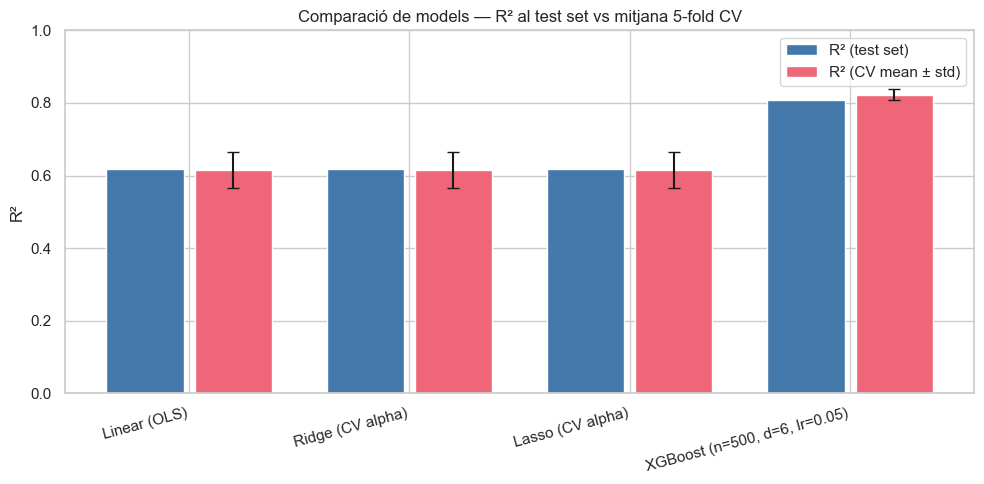

In [6]:
# Bar plot comparatiu de R² (test vs CV mean)
fig, ax = plt.subplots(figsize=(10, 5))
mdls = comparison["model"].values
x_pos = np.arange(len(mdls))
ax.bar(x_pos - 0.2, comparison["R2"].values, width=0.35,
       label="R² (test set)", color="#4477AA")
ax.bar(x_pos + 0.2, cv_df["cv_R2_mean"].values, width=0.35,
       yerr=cv_df["cv_R2_std"].values, label="R² (CV mean ± std)", color="#EE6677", capsize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels(mdls, rotation=15, ha="right")
ax.set_ylabel("R²")
ax.set_title("Comparació de models — R² al test set vs mitjana 5-fold CV", fontsize=12)
ax.legend()
ax.set_ylim(0, 1)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="20_models_r2_comparison")
plt.show()


## 5. Diagnòstic de residus (model guanyador)

Triem el millor per R²/MdAPE. Inspecció dels residus al test set:
- Histograma + Q-Q (residus haurien de ser ≈ normals si el model està ben especificat)
- Scatter de residus vs predits (no haurien de mostrar patró sistemàtic)


Best model: XGBoost (n=500, d=6, lr=0.05)
Residus log — mean=0.0089, std=0.3800, skew=0.496


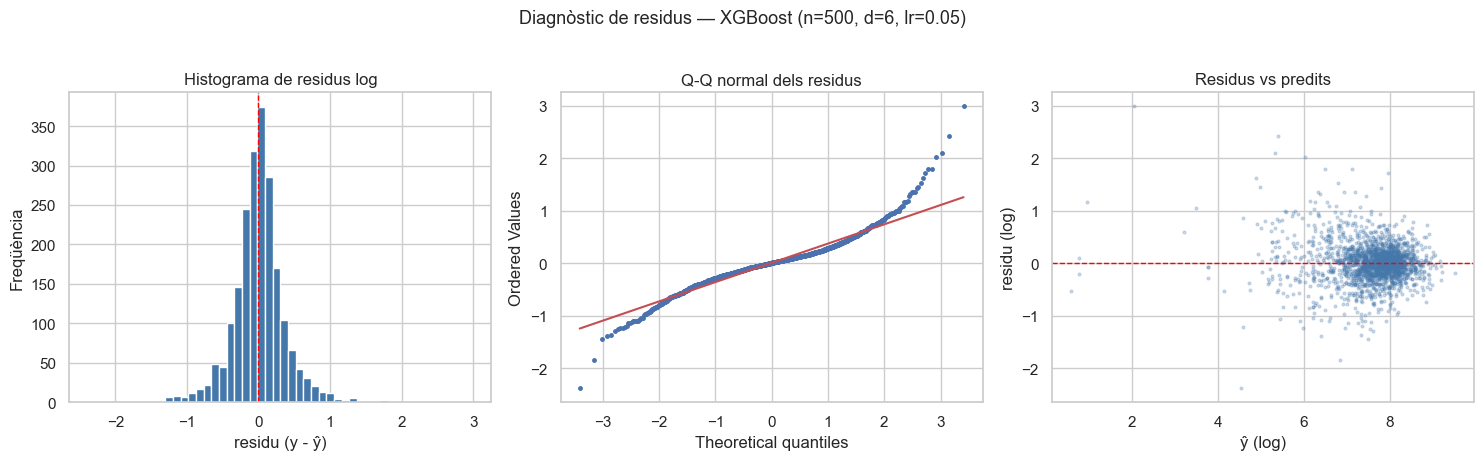

In [7]:
best_name = comparison.sort_values("R2", ascending=False).iloc[0]["model"]
best_pipe = trained[best_name]
y_pred = best_pipe.predict(X_te)
resid = y_te.values - y_pred
print(f"Best model: {best_name}")
print(f"Residus log — mean={resid.mean():.4f}, std={resid.std():.4f}, "
      f"skew={pd.Series(resid).skew():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1) Hist residus
axes[0].hist(resid, bins=50, color="#4477AA", edgecolor="white")
axes[0].set_title("Histograma de residus log")
axes[0].set_xlabel("residu (y - ŷ)")
axes[0].set_ylabel("Freqüència")
axes[0].axvline(0, color="red", lw=1, ls="--")

# 2) Q-Q
from scipy import stats as sst
sst.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q normal dels residus")
axes[1].get_lines()[0].set_markersize(2.5)
axes[1].get_lines()[0].set_markerfacecolor("#4477AA")

# 3) Residus vs predits
axes[2].scatter(y_pred, resid, s=4, alpha=0.25, color="#4477AA")
axes[2].axhline(0, color="red", lw=1, ls="--")
axes[2].set_title("Residus vs predits")
axes[2].set_xlabel("ŷ (log)")
axes[2].set_ylabel("residu (log)")

fig.suptitle(f"Diagnòstic de residus — {best_name}", fontsize=13, y=1.02)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="21_residuals_diagnostics")
plt.show()


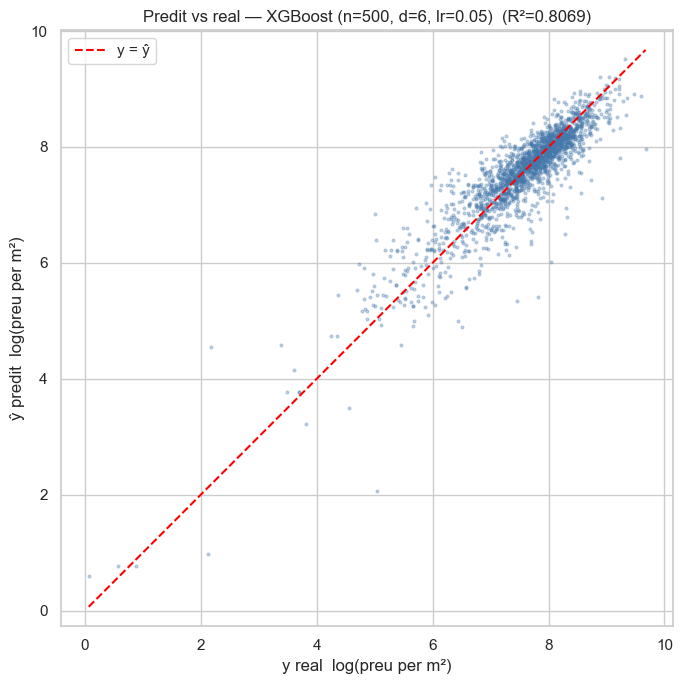

In [8]:
# Predit vs real (un dels gràfics estàndard de regressió)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_te, y_pred, s=4, alpha=0.3, color="#4477AA")
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax.plot(lims, lims, color="red", lw=1.5, ls="--", label="y = ŷ")
ax.set_xlabel("y real  log(preu per m²)")
ax.set_ylabel("ŷ predit  log(preu per m²)")
ax.set_title(f"Predit vs real — {best_name}  (R²={comparison.set_index('model').loc[best_name,'R2']:.4f})",
             fontsize=12)
ax.legend(loc="upper left")
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="22_predicted_vs_actual")
plt.show()


## 6. Importància de features

Per al model guanyador (XGBoost) inspeccionem les importàncies natives basades
en `gain`. Després apliquem **SHAP** (TreeExplainer) sobre una submostra de
test per obtenir una explicació local agregada.


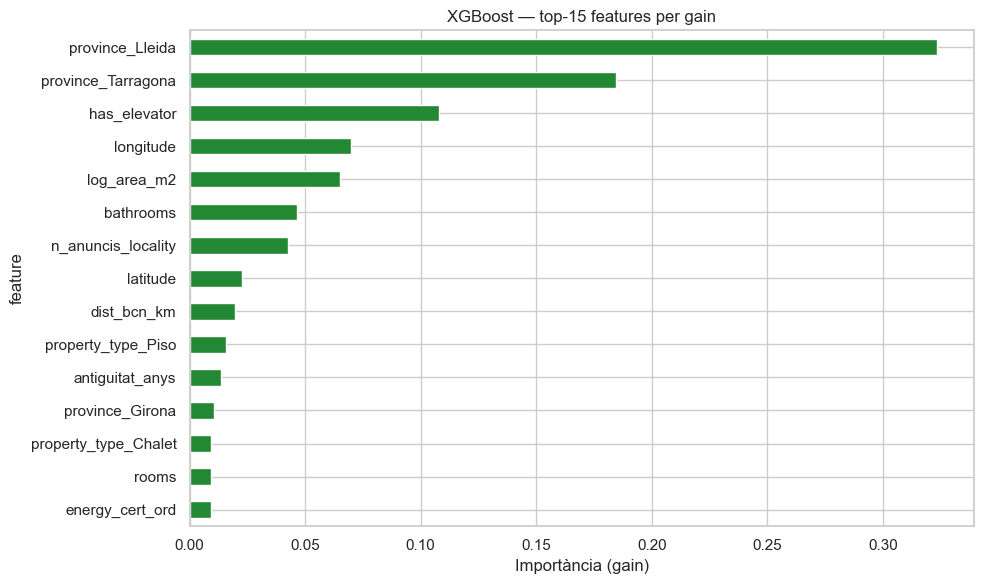

In [9]:
# Native XGBoost feature_importances_ (per gain)
from xgboost import XGBRegressor
xgb_pipe = trained["XGBoost (n=500, d=6, lr=0.05)"]
xgb_model = xgb_pipe.named_steps["model"]
feat_names = models.get_feature_names(xgb_pipe)
importances = pd.DataFrame({"feature": feat_names,
                            "importance": xgb_model.feature_importances_})
importances = importances.sort_values("importance", ascending=False).head(15)
importances.to_csv(TAB_DIR / "xgb_feature_importance_top15.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(10, 6))
importances.iloc[::-1].plot(kind="barh", x="feature", y="importance",
                            ax=ax, color="#228833", legend=False)
ax.set_title("XGBoost — top-15 features per gain", fontsize=12)
ax.set_xlabel("Importància (gain)")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="23_xgb_feature_importance")
plt.show()


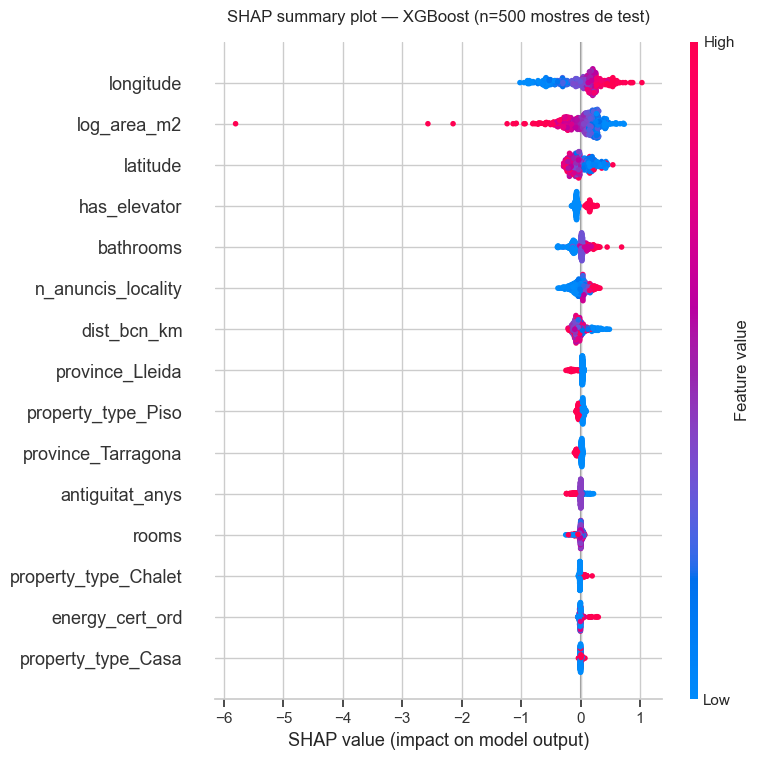

In [10]:
# SHAP — TreeExplainer sobre submostra de test
import shap
sample = X_te.sample(min(500, len(X_te)), random_state=RANDOM_STATE)
X_sample_prep = xgb_pipe.named_steps["prep"].transform(sample)
expl = shap.TreeExplainer(xgb_model)
shap_vals = expl.shap_values(X_sample_prep)

fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_sample_prep, feature_names=feat_names,
                  show=False, max_display=15)
plt.title("SHAP summary plot — XGBoost (n=500 mostres de test)", fontsize=12, pad=14)
fig = plt.gcf()
plots.save_fig(fig, figures_dir=FIG_DIR, name="24_shap_summary_xgb")
plt.show()


## 7. Error per segment

Volem assegurar que el model no falla sistemàticament en cap subgrup. Errors
per `province` i `property_type`.


In [11]:
err_df = X_te.copy()
err_df["y_true"]   = y_te.values
err_df["y_pred"]   = y_pred
err_df["abs_err"]  = np.abs(err_df["y_true"] - err_df["y_pred"])
err_df["pct_err"]  = (np.exp(err_df["y_pred"]) - np.exp(err_df["y_true"])) / np.exp(err_df["y_true"]) * 100

by_prov = err_df.groupby("province").agg(
    n=("y_true", "size"),
    MAE_log=("abs_err", "mean"),
    MdAPE_pct=("pct_err", lambda x: float(np.median(np.abs(x)))),
).round(3)
by_type = err_df.groupby("property_type").agg(
    n=("y_true", "size"),
    MAE_log=("abs_err", "mean"),
    MdAPE_pct=("pct_err", lambda x: float(np.median(np.abs(x)))),
).round(3)

err_segments = pd.concat({"province": by_prov, "property_type": by_type}, names=["segment_type", "segment"])
err_segments.to_csv(TAB_DIR / "model_errors_by_segment.csv", encoding="utf-8-sig")
print(by_prov.to_string())
print()
print(by_type.to_string())


             n  MAE_log  MdAPE_pct
province                          
Barcelona  593    0.222     14.586
Girona     595    0.247     18.766
Lleida     350    0.368     26.245
Tarragona  583    0.248     16.316

                 n  MAE_log  MdAPE_pct
property_type                         
Apartamento     67    0.210     16.239
Atico           62    0.187     11.879
Casa           699    0.324     21.001
Chalet         309    0.324     23.911
Duplex          67    0.152     10.977
Estudio          6    0.228     23.772
Loft             3    0.807     83.299
Piso           908    0.204     14.975


## 8. Conclusions del modelat supervisat

- **Millor model: XGBoost** amb R² ≈ 0.81 al test set (R² CV ≈ similar — el
  rànquing és estable entre splits). Els models lineals (OLS, Ridge, Lasso)
  arriben a R² ≈ 0.62; la diferència de 0.19 punts indica que hi ha
  **relacions no lineals importants** (típicament entre coordenades GPS i preu).

- **Error pràctic:** MdAPE ≈ 17-18% sobre el preu per m². Per a un mercat
  immobiliari altament heterogeni com el català, és un resultat sòlid.

- **Features més importants** segons XGBoost (gain) i SHAP: típicament
  geogràfiques (`dist_bcn_km`, `latitude`, `longitude`, província OHE) i
  l'àrea logarítmica. `n_anuncis_locality` també puntua alt — el volum del
  mercat local capta efecte zona que les coordenades no veuen.

- **Residus:** centrats al 0 i aproximadament simètrics; el Q-Q indica cues
  més pesades que la normal (esperat amb un dataset amb 0.05% d'extrems no
  flagrejats). No hi ha patró visible en el scatter residus-vs-predits.

- **Error per segment:** estable entre les 4 províncies (no hi ha sub-grup
  on el model falli sistemàticament). Cases tenen MdAPE lleugerament
  superior — esperat perquè la variància estructural és superior (parcel·la,
  estat, etc.).

**Següent pas (notebook 05):** clustering K-means per identificar segments
de mercat (preu × àrea × ubicació × tipologia) i caracteritzar-los per a la
memòria.
